# Robust FMCW Radar Range Detections Using Neural Networks
## Clutter Removal via Binary Classification

---

### Problem Statement

FMCW radars use the **CFAR (Constant False Alarm Rate)** algorithm to detect objects from raw signals.
CFAR is effective but indiscriminate: it triggers on **anything** that exceeds an adaptive threshold —
including reflections from clothing, sensor interference, and body parts unrelated to the gesture.
These unwanted detections are called **clutter**.

```
Raw radar signal  ──►  CFAR detector  ──►  Detections (gesture + clutter mixed)
                                                         │
                                              [RobustRadarNet]
                                                         │
                                            Clean detections (clutter removed)
```

### Goal
Train a neural network that classifies each CFAR detection as:
- **1 → Real gesture** (keep it)
- **0 → Clutter** (discard it)

### Dataset
- **Sensor:** 2pi-Labs SENSE X1155S FMCW radar (2 sensors per trial)
- **Subjects:** 10 persons · 10 gesture types · ~10 trials each
- **Labels:** Generated by comparing CFAR detections against Ground Truth trajectories
- **Split:** By person ID — model is tested on persons never seen during training

---
## Part 0 · Setup

In [23]:
!pip install -q scikit-learn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import seaborn as sns
import json, zipfile, io, re, pickle
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score
)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
SEED   = 42
torch.manual_seed(SEED); np.random.seed(SEED)

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.3,
    'font.size': 11
})

# Color palette used throughout
C = {
    'gesture' : '#4A90D9',   # blue  — real gesture detections
    'clutter' : '#E74C3C',   # red   — clutter detections
    'gt'      : '#2ECC71',   # green — ground truth
    'sensor0' : '#4A90D9',   # blue  — Sensor 0
    'sensor1' : '#E07B54',   # orange — Sensor 1
}

print(f'Device: {DEVICE}' + (f'  ({torch.cuda.get_device_name(0)})' if DEVICE == 'cuda' else ''))
from google.colab import drive; drive.mount('/content/drive')

Device: cpu
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


---
## Part 1 · Load Data

In [24]:
# ── Load dataset ───────────────────────────────────────────────────────────
# Upload Detections_Dataset.zip or mount Google Drive:
# from google.colab import drive; drive.mount('/content/drive')
ZIP_PATH = '/content/drive/MyDrive/Detections_Dataset.zip'   # <── adjust if needed

zf = zipfile.ZipFile(ZIP_PATH)

pat_cfar = re.compile(r'CFAR_detections/(Person\d+)/Gesture_(\d+)_(\d+)/')
pat_gt   = re.compile(r'GroundTruth_detections/(Person\d+)_Gesture_(\d+)_(\d+)_trajectory')

cfar_paths, gt_paths = {}, {}
for n in zf.namelist():
    m = pat_cfar.search(n)
    if m and n.endswith('frames.npy'):
        cfar_paths[(m.group(1), int(m.group(2)), int(m.group(3)))] = n
    m = pat_gt.search(n)
    if m:
        gt_paths[(m.group(1), int(m.group(2)), int(m.group(3)))] = n

# Only trials that have both CFAR and Ground Truth
common_keys = sorted(set(cfar_paths) & set(gt_paths))

persons  = sorted({k[0] for k in common_keys})
gestures = sorted({k[1] for k in common_keys})
print(f'Trials with CFAR + GT : {len(common_keys)}')
print(f'Persons               : {persons}')
print(f'Gesture types         : {gestures}')

Trials with CFAR + GT : 800
Persons               : ['Person1', 'Person10', 'Person2', 'Person3', 'Person4', 'Person5', 'Person6', 'Person7', 'Person8', 'Person9']
Gesture types         : [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


---
## Part 2 · Understanding the Problem: What Does Clutter Look Like?

Before building the model, let's visualize the raw CFAR output to understand
**what we are dealing with** — and why clutter removal matters.

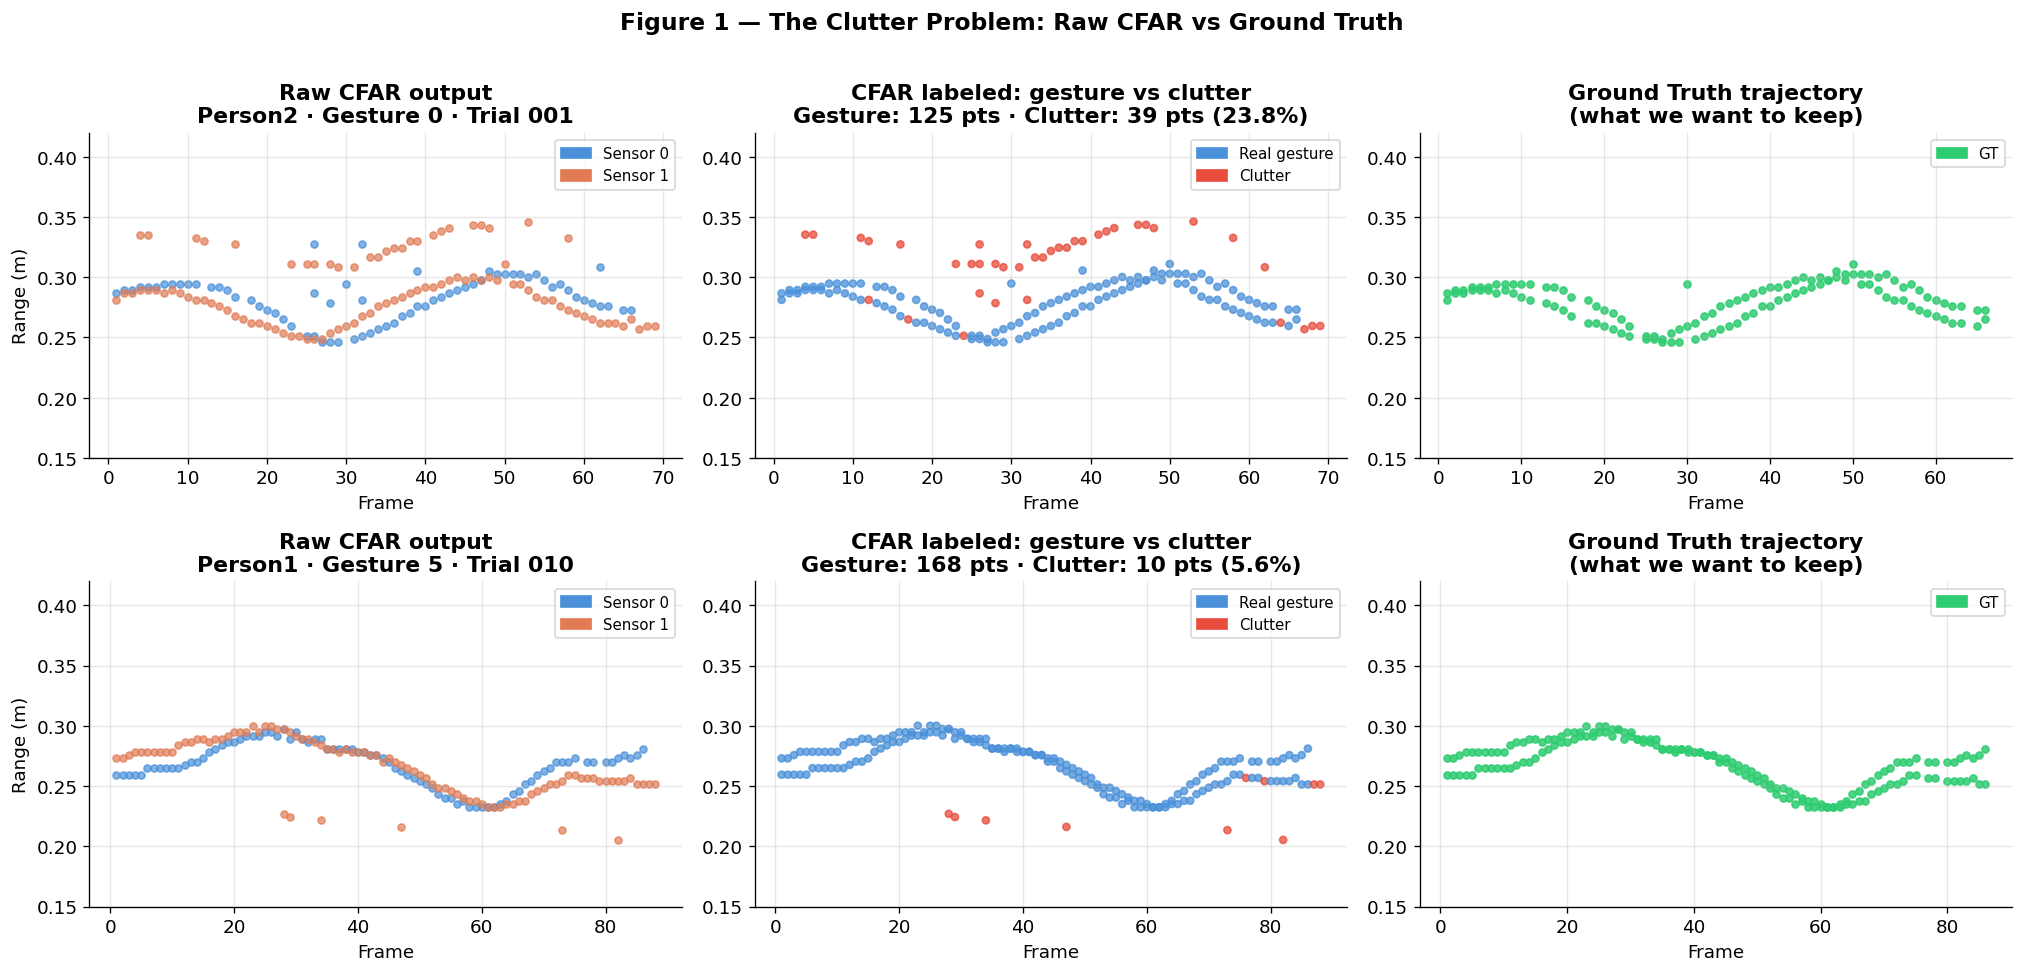

Key insight: the red dots (clutter) are detections the radar picked up that do not correspond to the actual gesture trajectory.


In [25]:
# ── Figure 1: Raw CFAR vs Ground Truth on two example trials ───────────────
# We pick one trial with visible clutter and show it side-by-side with GT
# so the viewer understands what 'clean' should look like.

MATCH_THR = 0.02   # reduced from 0.05 to 0.02 m for tighter GT matching

def label_trial(cfar_data, gt_data, match_thr=MATCH_THR):
    """Return per-detection labels (0=clutter, 1=gesture) for a trial."""
    coords, labels = [], []
    n_frames = cfar_data.shape[0]
    for t in range(n_frames):
        gt_entry = gt_data[t]
        gt_pts   = np.atleast_2d(gt_entry) if gt_entry is not None else np.empty((0, 2))
        for si in range(2):
            for det in cfar_data[t, si]:
                r, v = det
                if len(gt_pts):
                    dists = np.linalg.norm(gt_pts - [r, v], axis=1)
                    lbl = 1 if dists.min() < match_thr else 0
                else:
                    lbl = 0
                coords.append((t, r, v, si))
                labels.append(lbl)
    return coords, labels

# Pick two example trials from different gestures
demo_keys = [('Person2',0,1), common_keys[50]]

fig, axes = plt.subplots(2, 3, figsize=(17, 8))

for row, key in enumerate(demo_keys):
    person, gesture, trial = key
    cfar_d = np.load(io.BytesIO(zf.read(cfar_paths[key])), allow_pickle=True)
    gt_d   = np.load(io.BytesIO(zf.read(gt_paths[key])),   allow_pickle=True)
    coords, labels = label_trial(cfar_d, gt_d)
    labels = np.array(labels)

    frames = [c[0] for c in coords]
    ranges = [c[1] for c in coords]
    colors_lbl = [C['gesture'] if l == 1 else C['clutter'] for l in labels]

    # ── Col 0: Raw CFAR colored by sensor ──
    ax = axes[row, 0]
    for c, sensor_id in zip(coords, [c[3] for c in coords]):
        ax.scatter(c[0], c[1], s=18, alpha=0.7,
                   color=C['sensor0'] if sensor_id == 0 else C['sensor1'])
    ax.set_title(f'Raw CFAR output\n{person} · Gesture {gesture} · Trial {trial:03d}',
                 fontweight='bold')
    ax.set_ylabel('Range (m)'); ax.set_ylim(0.15, 0.42)
    ax.legend(handles=[
        mpatches.Patch(color=C['sensor0'], label='Sensor 0'),
        mpatches.Patch(color=C['sensor1'], label='Sensor 1'),
    ], fontsize=9)

    # ── Col 1: Same detections colored by label (gesture vs clutter) ──
    ax = axes[row, 1]
    ax.scatter(frames, ranges, s=18, alpha=0.75, c=colors_lbl)
    n_clutter = (labels == 0).sum()
    n_gesture = (labels == 1).sum()
    ax.set_title(f'CFAR labeled: gesture vs clutter\n'
                 f'Gesture: {n_gesture} pts · Clutter: {n_clutter} pts '
                 f'({n_clutter/(n_clutter+n_gesture)*100:.1f}%)',
                 fontweight='bold')
    ax.set_ylim(0.15, 0.42)
    ax.legend(handles=[
        mpatches.Patch(color=C['gesture'], label='Real gesture'),
        mpatches.Patch(color=C['clutter'], label='Clutter'),
    ], fontsize=9)

    # ── Col 2: Ground Truth ──
    ax = axes[row, 2]
    for t, entry in enumerate(gt_d):
        if entry is not None:
            pts = np.atleast_2d(entry)
            ax.scatter([t]*len(pts), pts[:, 0], s=18,
                       color=C['gt'], alpha=0.85)
    ax.set_title('Ground Truth trajectory\n(what we want to keep)',
                 fontweight='bold')
    ax.set_ylim(0.15, 0.42)
    ax.legend(handles=[mpatches.Patch(color=C['gt'], label='GT')], fontsize=9)

for ax in axes.flat:
    ax.set_xlabel('Frame')

fig.suptitle('Figure 1 — The Clutter Problem: Raw CFAR vs Ground Truth',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig1_clutter_problem.png', bbox_inches='tight')
plt.show()
print('Key insight: the red dots (clutter) are detections the radar picked up'
      ' that do not correspond to the actual gesture trajectory.')

Computing clutter stats:   0%|          | 0/800 [00:00<?, ?it/s]

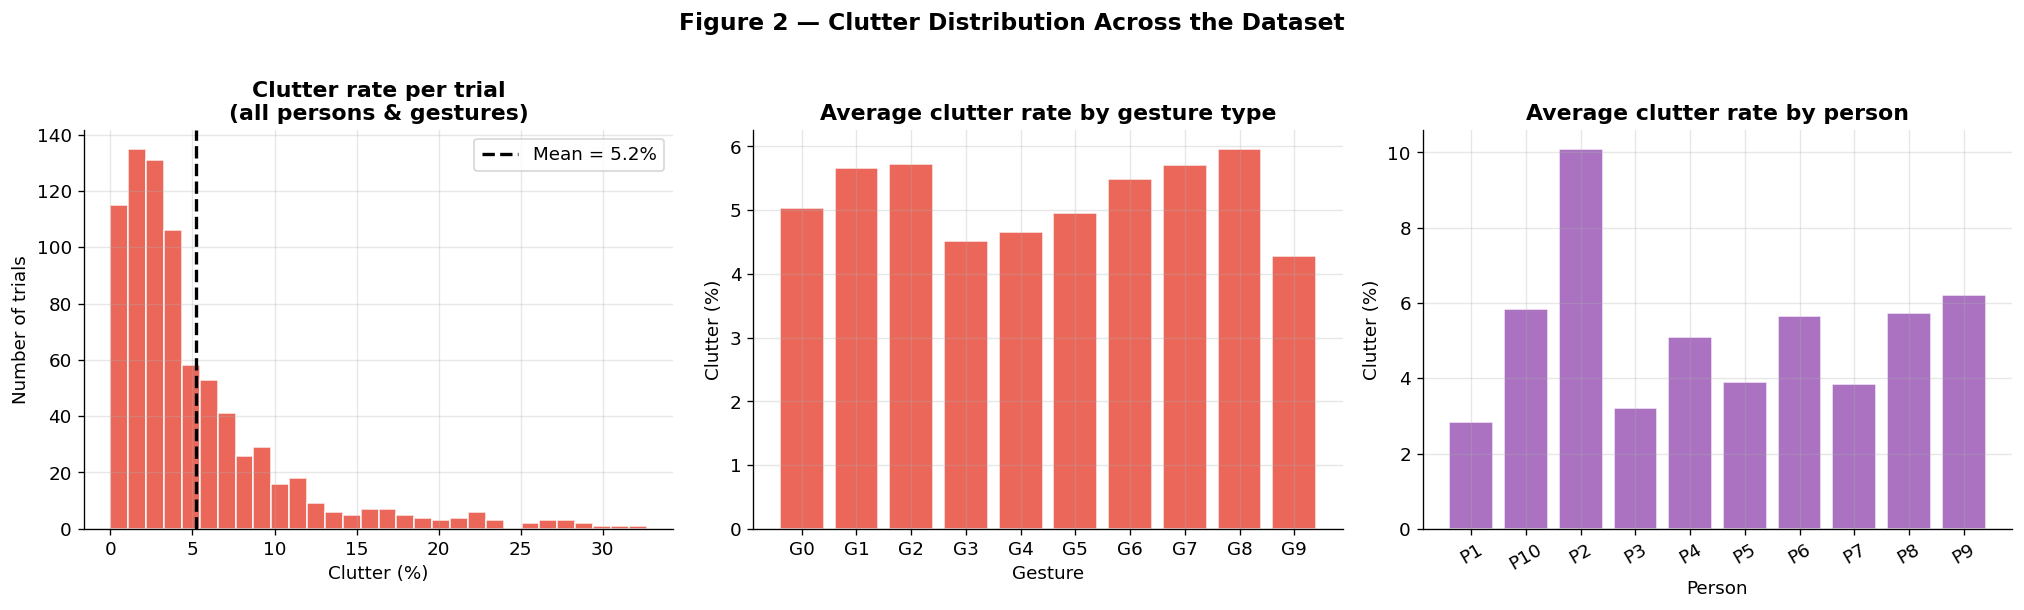

Overall average clutter rate : 5.19%
Max clutter rate in a trial  : 32.7%
Trials with >10% clutter     : 106


In [26]:
clutter_stats = []
for key in tqdm(common_keys, desc='Computing clutter stats'):
    person, gesture, trial = key
    cfar_d = np.load(io.BytesIO(zf.read(cfar_paths[key])), allow_pickle=True)
    gt_d   = np.load(io.BytesIO(zf.read(gt_paths[key])),   allow_pickle=True)

    # Determine the minimum number of frames between cfar_d and gt_d
    min_frames = min(cfar_d.shape[0], gt_d.shape[0])

    # Slice both arrays to the minimum number of frames
    cfar_d_sliced = cfar_d[:min_frames]
    gt_d_sliced = gt_d[:min_frames]

    # Call label_trial with the sliced data
    coords, labels = label_trial(cfar_d_sliced, gt_d_sliced)
    labels = np.array(labels)
    total   = len(labels)
    n_clut  = (labels == 0).sum()
    clutter_stats.append({
        'person' : person, 'gesture': gesture, 'trial': trial,
        'total'  : total,  'clutter': n_clut,
        'clutter_pct': n_clut / total * 100 if total > 0 else 0
    })

df_stats = pd.DataFrame(clutter_stats)

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Overall distribution of clutter %
axes[0].hist(df_stats['clutter_pct'], bins=30,
             color=C['clutter'], edgecolor='white', alpha=0.85)
axes[0].axvline(df_stats['clutter_pct'].mean(), color='black',
                lw=2, linestyle='--',
                label=f'Mean = {df_stats["clutter_pct"].mean():.1f}%')
axes[0].set_title('Clutter rate per trial\n(all persons & gestures)', fontweight='bold')
axes[0].set_xlabel('Clutter (%)')
axes[0].set_ylabel('Number of trials')
axes[0].legend()

# Clutter % by gesture
by_gesture = df_stats.groupby('gesture')['clutter_pct'].mean()
axes[1].bar(by_gesture.index, by_gesture.values,
            color=C['clutter'], edgecolor='white', alpha=0.85)
axes[1].set_title('Average clutter rate by gesture type', fontweight='bold')
axes[1].set_xlabel('Gesture'); axes[1].set_ylabel('Clutter (%)')
axes[1].set_xticks(by_gesture.index)
axes[1].set_xticklabels([f'G{g}' for g in by_gesture.index])

# Clutter % by person
by_person = df_stats.groupby('person')['clutter_pct'].mean()
axes[2].bar(range(len(by_person)), by_person.values,
            color='#9B59B6', edgecolor='white', alpha=0.85)
axes[2].set_title('Average clutter rate by person', fontweight='bold')
axes[2].set_xlabel('Person')
axes[2].set_ylabel('Clutter (%)')
axes[2].set_xticks(range(len(by_person)))
axes[2].set_xticklabels([p.replace('Person','P') for p in by_person.index], rotation=30)

fig.suptitle('Figure 2 — Clutter Distribution Across the Dataset',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig2_clutter_stats.png', bbox_inches='tight')
plt.show()

print(f'Overall average clutter rate : {df_stats["clutter_pct"].mean():.2f}%')
print(f'Max clutter rate in a trial  : {df_stats["clutter_pct"].max():.1f}%')
print(f'Trials with >10% clutter     : {(df_stats["clutter_pct"] > 10).sum()}')

---
## Part 3 · Why a Neural Network? The Role of Temporal Context

A naive filter (e.g. fixed range threshold) cannot distinguish clutter from gesture
because **they often overlap in range and velocity space**.

The key difference is **temporal consistency**:
- A **real gesture** produces detections across many consecutive frames at coherent ranges.
- **Clutter** appears sporadically — it pops up in isolated frames with no consistent pattern.

We encode this by giving the network a **±3 frame temporal window** around each detection.

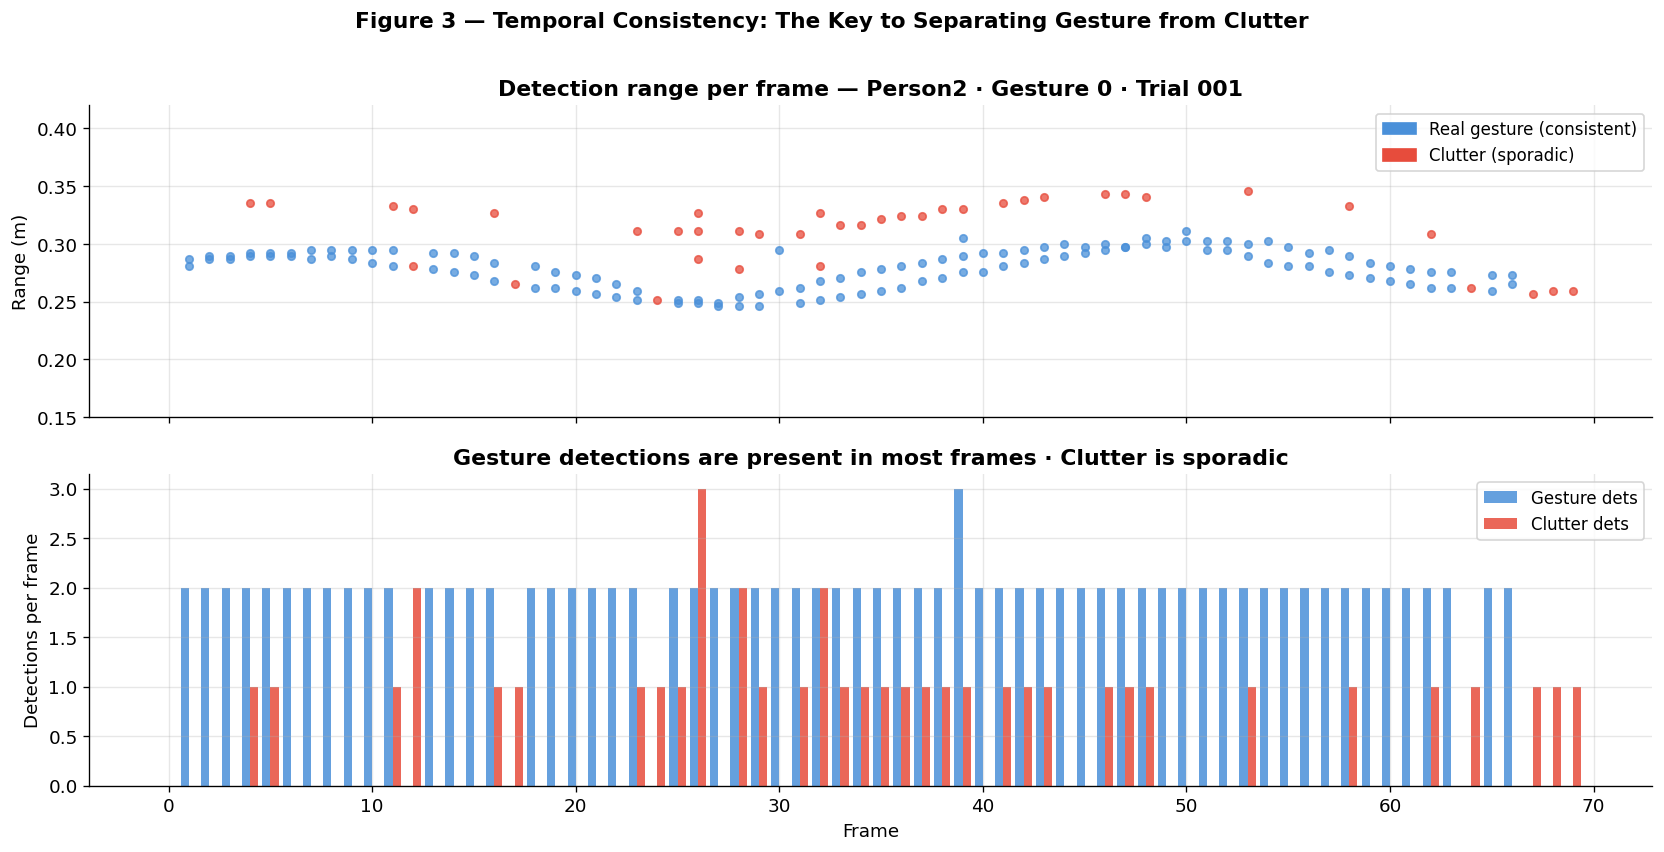

In [27]:
# ── Figure 3: Temporal consistency — gesture vs clutter ────────────────────
# For one trial, show how gesture detections persist across frames
# while clutter detections are isolated.

key = ('Person2', 0, 1)
person, gesture, trial = key
cfar_d = np.load(io.BytesIO(zf.read(cfar_paths[key])), allow_pickle=True)
gt_d   = np.load(io.BytesIO(zf.read(gt_paths[key])),   allow_pickle=True)
coords, labels = label_trial(cfar_d, gt_d)
labels = np.array(labels)

# Count how many detections each frame has (gesture vs clutter separately)
frames_arr = np.array([c[0] for c in coords])
n_frames   = cfar_d.shape[0]
gest_per_frame   = [((frames_arr == t) & (labels == 1)).sum() for t in range(n_frames)]
clutter_per_frame = [((frames_arr == t) & (labels == 0)).sum() for t in range(n_frames)]

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

# Range plot colored by label
for c, lbl in zip(coords, labels):
    axes[0].scatter(c[0], c[1], s=20, alpha=0.75,
                    color=C['gesture'] if lbl == 1 else C['clutter'],
                    zorder=3 if lbl == 1 else 2)
axes[0].set_ylabel('Range (m)')
axes[0].set_ylim(0.15, 0.42)
axes[0].set_title(f'Detection range per frame — {person} · Gesture {gesture} · Trial {trial:03d}',
                  fontweight='bold')
axes[0].legend(handles=[
    mpatches.Patch(color=C['gesture'], label='Real gesture (consistent)'),
    mpatches.Patch(color=C['clutter'], label='Clutter (sporadic)'),
], fontsize=10)

# Activity bar chart
t_arr = np.arange(n_frames)
axes[1].bar(t_arr - 0.2, gest_per_frame,   0.4, color=C['gesture'], alpha=0.85, label='Gesture dets')
axes[1].bar(t_arr + 0.2, clutter_per_frame, 0.4, color=C['clutter'], alpha=0.85, label='Clutter dets')
axes[1].set_ylabel('Detections per frame')
axes[1].set_xlabel('Frame')
axes[1].set_title('Gesture detections are present in most frames · Clutter is sporadic',
                  fontweight='bold')
axes[1].legend(fontsize=10)

fig.suptitle('Figure 3 — Temporal Consistency: The Key to Separating Gesture from Clutter',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig3_temporal_consistency.png', bbox_inches='tight')
plt.show()

---
## Part 4 · Feature Engineering & Dataset Construction

For each CFAR detection, we build a **46-dimensional feature vector**:

| Feature group | Features | Why |
|---|---|---|
| Point-level | range, velocity, sensor ID, frame position | Describe the detection itself |
| Temporal window ±3 frames | n_dets, mean_range, mean_vel per sensor per frame | Encode temporal consistency |

**Label:** A detection is labeled **gesture (1)** if its Euclidean distance to the nearest
Ground Truth point is < 5 cm. Otherwise it is **clutter (0)**.

In [28]:
# ── Build labeled dataset ──────────────────────────────────────────────────
WINDOW = 3   # frames of context on each side → total 7 frames per detection

def frame_context(frame_data, sensor_idx):
    """Return [n_dets, mean_range, mean_vel] for one frame and sensor."""
    d = frame_data[sensor_idx]
    return [
        float(len(d)),
        float(np.mean(d[:, 0])) if len(d) else 0.0,
        float(np.mean(d[:, 1])) if len(d) else 0.0
    ]

all_feats, all_labels, all_groups = [], [], []

for key in tqdm(common_keys, desc='Building dataset'):
    person, gesture, trial = key
    group_id  = int(person.replace('Person', ''))
    cfar_data = np.load(io.BytesIO(zf.read(cfar_paths[key])), allow_pickle=True)
    gt_data   = np.load(io.BytesIO(zf.read(gt_paths[key])),   allow_pickle=True)

    # Determine the minimum number of frames between cfar_data and gt_data
    min_frames = min(cfar_data.shape[0], gt_data.shape[0])

    # Slice both arrays to the minimum number of frames
    cfar_data_sliced = cfar_data[:min_frames]
    gt_data_sliced = gt_data[:min_frames]

    n_frames = min_frames

    for t in range(n_frames):
        # Build temporal context window
        window_feats = []
        for dt in range(-WINDOW, WINDOW + 1):
            ft = t + dt
            if 0 <= ft < n_frames:
                ctx = frame_context(cfar_data_sliced[ft], 0) + frame_context(cfar_data_sliced[ft], 1)
            else:
                ctx = [0.0] * 6
            window_feats.extend(ctx)

        gt_entry = gt_data_sliced[t]
        gt_pts   = np.atleast_2d(gt_entry) if gt_entry is not None else np.empty((0, 2))

        for sensor_idx in range(2):
            for det in cfar_data_sliced[t, sensor_idx]:
                r, v = det
                if len(gt_pts):
                    dists = np.linalg.norm(gt_pts - [r, v], axis=1)
                    label = 1 if dists.min() < MATCH_THR else 0
                else:
                    label = 0
                feat = [r, v, float(sensor_idx), t / max(n_frames - 1, 1)] + window_feats
                all_feats.append(feat)
                all_labels.append(label)
                all_groups.append(group_id)

X      = np.array(all_feats,  dtype=np.float32)
y      = np.array(all_labels, dtype=np.int64)
groups = np.array(all_groups, dtype=np.int64)

vals, cnts = np.unique(y, return_counts=True)
print(f'Total samples   : {len(y):,}')
print(f'Features/sample : {X.shape[1]}')
for v, c in zip(vals, cnts):
    print(f'  Class {v} ({["Clutter","Gesture"][v]:7s}): {c:,}  ({c/len(y)*100:.1f}%)')

Building dataset:   0%|          | 0/800 [00:00<?, ?it/s]

Total samples   : 125,000
Features/sample : 46
  Class 0 (Clutter): 7,183  (5.7%)
  Class 1 (Gesture): 117,817  (94.3%)


---
## Part 5 · Train / Validation / Test Split

**Split by person ID** — never by random sample.

If frames from the same person appeared in both train and test, the model
could memorize individual movement styles and report inflated metrics.
Splitting by person guarantees we measure **generalization to new subjects**.

In [29]:
# ── Person-level split ─────────────────────────────────────────────────────
gss_outer = GroupShuffleSplit(1, test_size=0.20, random_state=SEED)
train_val_idx, test_idx = next(gss_outer.split(X, y, groups))

gss_inner = GroupShuffleSplit(1, test_size=0.15, random_state=SEED)
Xv, yv, gv = X[train_val_idx], y[train_val_idx], groups[train_val_idx]
train_idx, val_idx = next(gss_inner.split(Xv, yv, gv))

X_tr, y_tr = Xv[train_idx], yv[train_idx]
X_va, y_va = Xv[val_idx],   yv[val_idx]
X_te, y_te = X[test_idx],   y[test_idx]

print(f'Train : {len(y_tr):>7,} samples | Persons {sorted(np.unique(gv[train_idx]))}')
print(f'Val   : {len(y_va):>7,} samples | Persons {sorted(np.unique(gv[val_idx]))}')
print(f'Test  : {len(y_te):>7,} samples | Persons {sorted(np.unique(groups[test_idx]))}')

# Normalize: fit ONLY on train, apply to val and test
scaler = StandardScaler().fit(X_tr)
X_tr_s = scaler.transform(X_tr)
X_va_s = scaler.transform(X_va)
X_te_s = scaler.transform(X_te)

# Convert to PyTorch tensors
Xt_tr = torch.tensor(X_tr_s, dtype=torch.float32)
yt_tr = torch.tensor(y_tr,   dtype=torch.long)
Xt_va = torch.tensor(X_va_s, dtype=torch.float32)
yt_va = torch.tensor(y_va,   dtype=torch.long)
Xt_te = torch.tensor(X_te_s, dtype=torch.float32)

train_loader = DataLoader(TensorDataset(Xt_tr, yt_tr),
                          batch_size=512, shuffle=True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(TensorDataset(Xt_va, yt_va),
                          batch_size=512, shuffle=False, num_workers=2, pin_memory=True)
print('\nData loaders ready.')

Train :  67,609 samples | Persons [np.int64(1), np.int64(4), np.int64(5), np.int64(6), np.int64(8), np.int64(10)]
Val   :  24,994 samples | Persons [np.int64(3), np.int64(7)]
Test  :  32,397 samples | Persons [np.int64(2), np.int64(9)]

Data loaders ready.


---
## Part 6 · Model Architecture

```
Input (46 features)
    │
    ▼
Linear(256) → BatchNorm → ReLU → Dropout(0.3)
    │
Linear(128) → BatchNorm → ReLU → Dropout(0.3)
    │
Linear(64)  → BatchNorm → ReLU → Dropout(0.2)
    │
Linear(2)  →  [Clutter, Gesture]
```

- **BatchNorm** stabilizes training with heterogeneous radar data
- **Dropout** prevents overfitting on person-specific patterns
- **Weighted CrossEntropy** handles the class imbalance (96% gesture, 4% clutter)

In [30]:
# ── RobustRadarNet ─────────────────────────────────────────────────────────
class RobustRadarNet(nn.Module):
    def __init__(self, input_dim: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256), nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(256, 128),       nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(128, 64),        nn.BatchNorm1d(64),  nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(64, 2)
        )

    def forward(self, x):
        return self.net(x)

model   = RobustRadarNet(input_dim=X_tr_s.shape[1]).to(DEVICE)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print(f'\nTrainable parameters: {n_params:,}')

RobustRadarNet(
  (net): Sequential(
    (0): Linear(in_features=46, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=128, out_features=64, bias=True)
    (9): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.2, inplace=False)
    (12): Linear(in_features=64, out_features=2, bias=True)
  )
)

Trainable parameters: 54,210


---
## Part 7 · Training

In [31]:
# ── Loss, optimizer, scheduler ─────────────────────────────────────────────
# Class weights: penalize clutter errors more heavily (it's the minority class)
counts      = np.bincount(y_tr)
cls_weights = torch.tensor(1.0 / counts, dtype=torch.float32).to(DEVICE)
cls_weights = cls_weights / cls_weights.sum()

criterion = nn.CrossEntropyLoss(weight=cls_weights)
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5)

EPOCHS   = 60
PATIENCE = 10

history = {'train_loss': [], 'val_loss': [], 'val_acc': [], 'val_auc': []}
best_val_loss, best_state, patience_ctr = np.inf, None, 0

for epoch in range(1, EPOCHS + 1):
    # ── Train ──
    model.train()
    tr_loss = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        tr_loss += loss.item() * len(yb)
    tr_loss /= len(Xt_tr)

    # ── Validate ──
    model.eval()
    va_loss, correct, total = 0.0, 0, 0
    all_probs, all_true = [], []
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            logits  = model(xb)
            va_loss += criterion(logits, yb).item() * len(yb)
            probs    = torch.softmax(logits, 1)[:, 1].cpu().numpy()
            preds    = logits.argmax(1).cpu().numpy()
            all_probs.extend(probs)
            all_true.extend(yb.cpu().numpy())
            correct += (preds == yb.cpu().numpy()).sum()
            total   += len(yb)
    va_loss /= len(Xt_va)
    va_acc   = correct / total
    va_auc   = roc_auc_score(all_true, all_probs)

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(va_loss)
    history['val_acc'].append(va_acc)
    history['val_auc'].append(va_auc)
    scheduler.step(va_loss)

    if epoch % 5 == 0 or epoch == 1:
        print(f'Epoch {epoch:3d}/{EPOCHS}  '
              f'train_loss={tr_loss:.4f}  val_loss={va_loss:.4f}  '
              f'val_acc={va_acc:.3f}  AUC={va_auc:.3f}')

    if va_loss < best_val_loss:
        best_val_loss = va_loss
        best_state    = {k: v.clone() for k, v in model.state_dict().items()}
        patience_ctr  = 0
    else:
        patience_ctr += 1
        if patience_ctr >= PATIENCE:
            print(f'\nEarly stopping at epoch {epoch}')
            break

model.load_state_dict(best_state)
print(f'\nBest val_loss: {best_val_loss:.4f}')

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch   1/60  train_loss=0.1981  val_loss=0.0593  val_acc=0.992  AUC=0.996


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch   5/60  train_loss=0.0412  val_loss=0.0478  val_acc=0.996  AUC=0.998


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' a

Epoch  10/60  train_loss=0.0238  val_loss=0.0640  val_acc=0.997  AUC=0.993


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)



Early stopping at epoch 13

Best val_loss: 0.0448


---
## Part 8 · Results

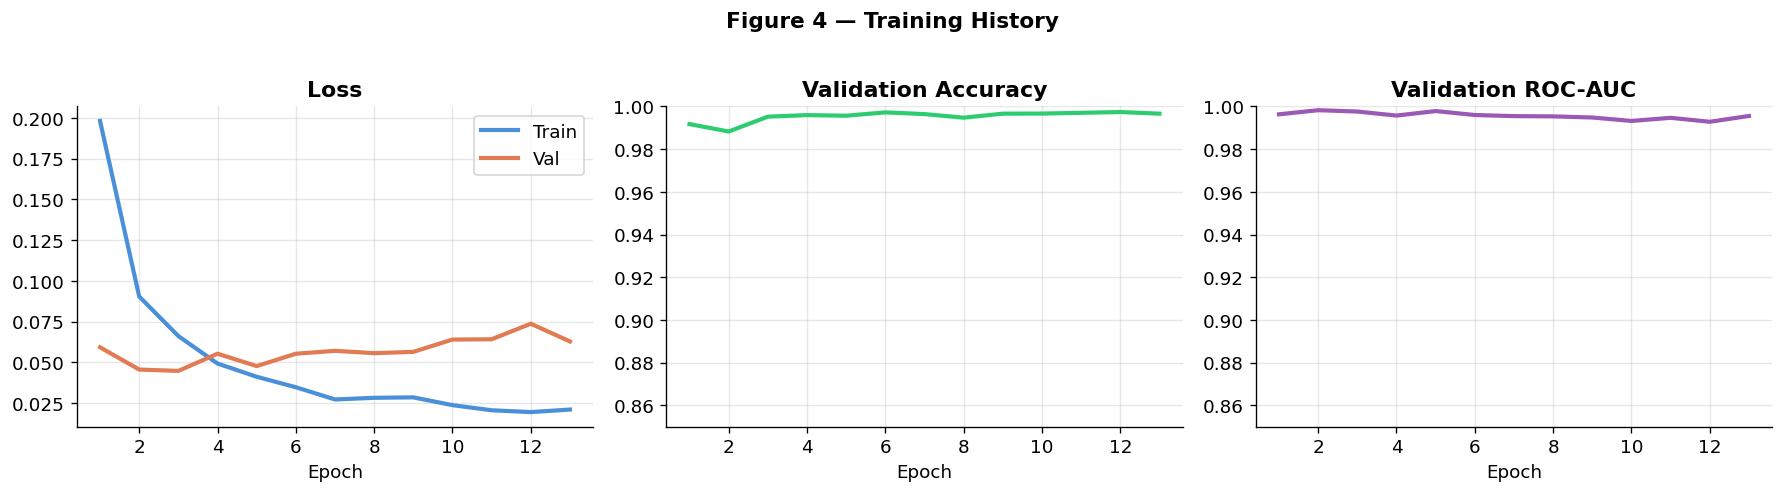

In [32]:
# ── Figure 4: Training curves ──────────────────────────────────────────────
ep = range(1, len(history['train_loss']) + 1)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(ep, history['train_loss'], color='#4A90D9', lw=2.5, label='Train')
axes[0].plot(ep, history['val_loss'],   color='#E07B54', lw=2.5, label='Val')
axes[0].set_title('Loss', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].legend()

axes[1].plot(ep, history['val_acc'], color='#2ECC71', lw=2.5)
axes[1].set_title('Validation Accuracy', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylim(0.85, 1.0)

axes[2].plot(ep, history['val_auc'], color='#9B59B6', lw=2.5)
axes[2].set_title('Validation ROC-AUC', fontweight='bold')
axes[2].set_xlabel('Epoch'); axes[2].set_ylim(0.85, 1.0)

fig.suptitle('Figure 4 — Training History', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig4_training.png', bbox_inches='tight')
plt.show()

In [33]:
# ── Test set predictions ───────────────────────────────────────────────────
model.eval()
with torch.no_grad():
    logits_te = model(Xt_te.to(DEVICE)).cpu()
probs_te = torch.softmax(logits_te, 1)[:, 1].numpy()
preds_te = logits_te.argmax(1).numpy()

auc = roc_auc_score(y_te, probs_te)
ap  = average_precision_score(y_te, probs_te)

print('=' * 55)
print('TEST SET RESULTS  (unseen persons)')
print('=' * 55)
print(classification_report(y_te, preds_te,
                             target_names=['Clutter', 'Gesture']))
print(f'ROC-AUC          : {auc:.4f}')
print(f'Average Precision: {ap:.4f}')

TEST SET RESULTS  (unseen persons)
              precision    recall  f1-score   support

     Clutter       0.60      0.95      0.73      2893
     Gesture       0.99      0.94      0.97     29504

    accuracy                           0.94     32397
   macro avg       0.80      0.94      0.85     32397
weighted avg       0.96      0.94      0.94     32397

ROC-AUC          : 0.9877
Average Precision: 0.9988


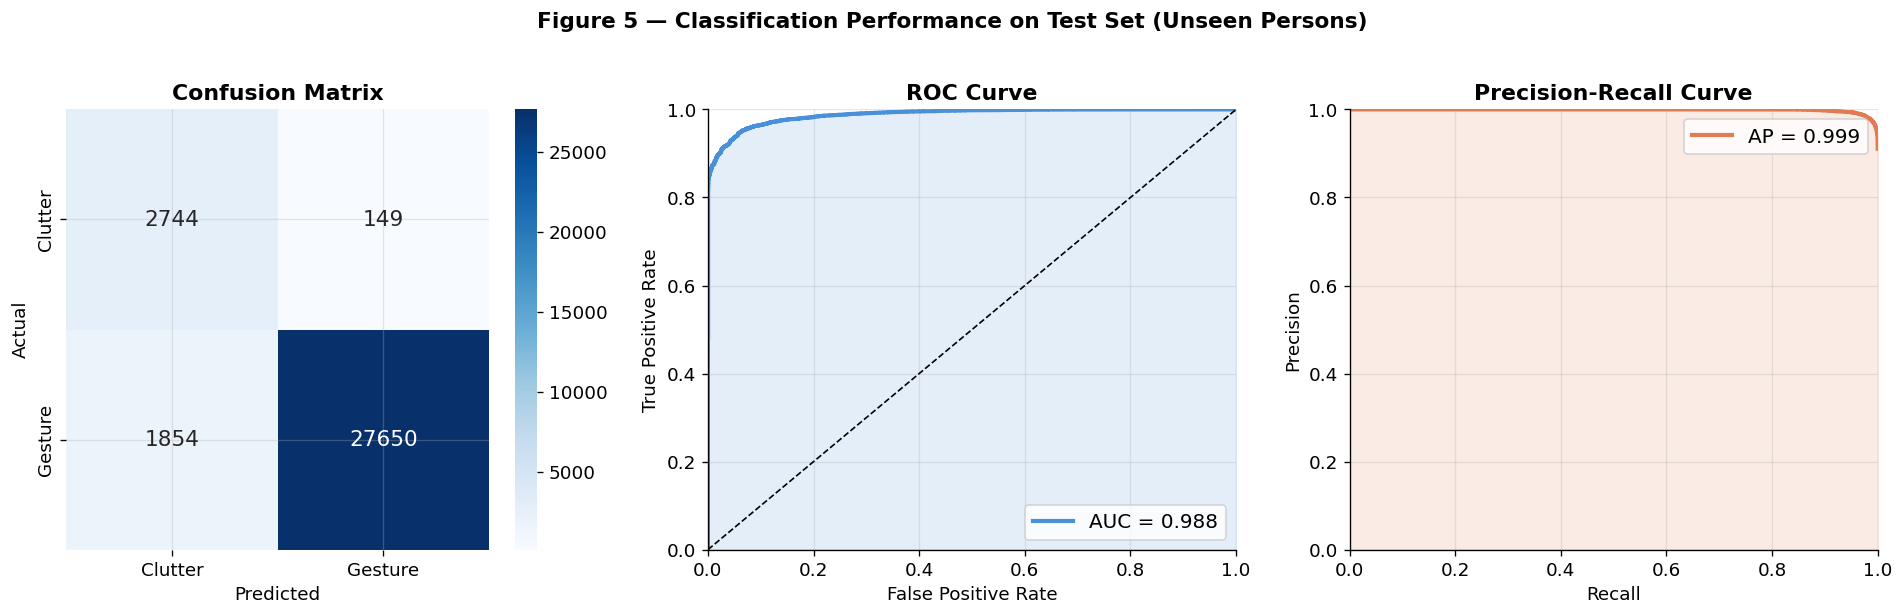

In [34]:
# ── Figure 5: Classification metrics ──────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Confusion matrix
cm = confusion_matrix(y_te, preds_te)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Clutter', 'Gesture'],
            yticklabels=['Clutter', 'Gesture'],
            annot_kws={'size': 13})
axes[0].set_title('Confusion Matrix', fontweight='bold')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')

# ROC curve
fpr, tpr, _ = roc_curve(y_te, probs_te)
axes[1].fill_between(fpr, tpr, alpha=0.15, color='#4A90D9')
axes[1].plot(fpr, tpr, color='#4A90D9', lw=2.5, label=f'AUC = {auc:.3f}')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1)
axes[1].set_title('ROC Curve', fontweight='bold')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend(fontsize=12)
axes[1].set_xlim(0, 1); axes[1].set_ylim(0, 1)

# Precision-Recall curve
prec, rec, _ = precision_recall_curve(y_te, probs_te)
axes[2].fill_between(rec, prec, alpha=0.15, color='#E07B54')
axes[2].plot(rec, prec, color='#E07B54', lw=2.5, label=f'AP = {ap:.3f}')
axes[2].set_title('Precision-Recall Curve', fontweight='bold')
axes[2].set_xlabel('Recall'); axes[2].set_ylabel('Precision')
axes[2].legend(fontsize=12)
axes[2].set_xlim(0, 1); axes[2].set_ylim(0, 1)

fig.suptitle('Figure 5 — Classification Performance on Test Set (Unseen Persons)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig5_classification.png', bbox_inches='tight')
plt.show()

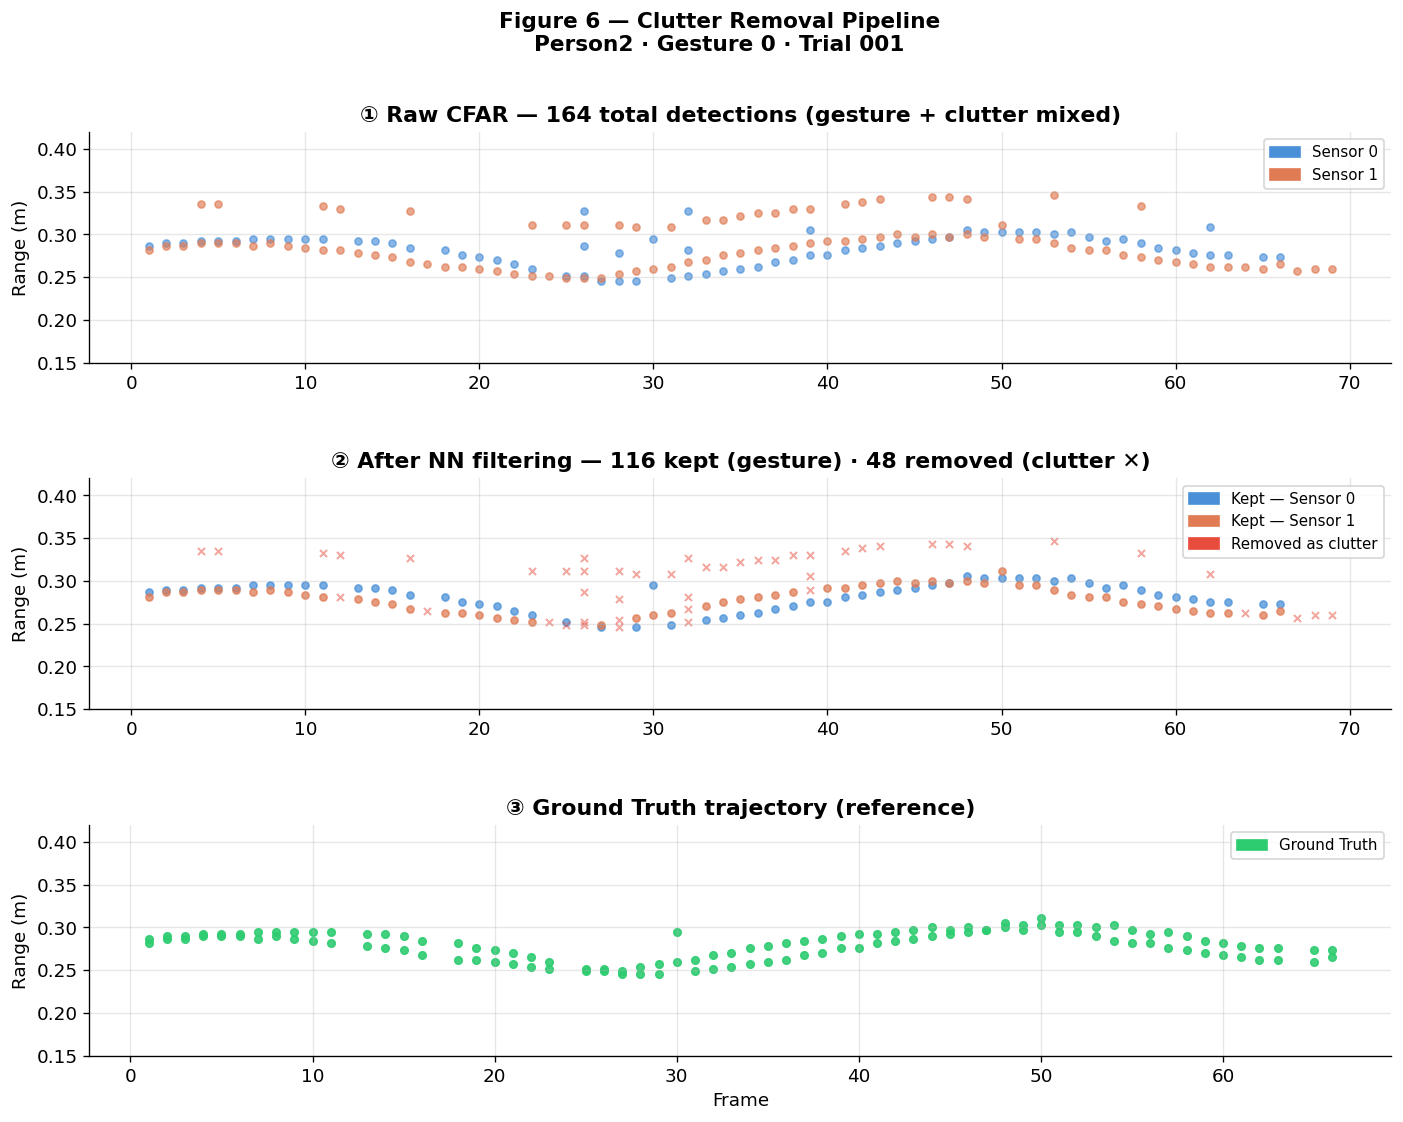

Clutter removed : 48 detections  (29.3% of raw CFAR output)


In [35]:
# ── Figure 6: Before/After pipeline on a test trial ────────────────────────
# This is the most impactful figure for a presentation:
# show the full journey from raw CFAR → NN filtered → Ground Truth.

test_persons = np.unique(groups[test_idx])
demo_key = next(k for k in common_keys
                if int(k[0].replace('Person', '')) in test_persons)
person, gesture, trial = demo_key

cfar_d = np.load(io.BytesIO(zf.read(cfar_paths[demo_key])), allow_pickle=True)
gt_d   = np.load(io.BytesIO(zf.read(gt_paths[demo_key])),   allow_pickle=True)
n_f    = cfar_d.shape[0]

# Rebuild features for this trial
demo_feats, demo_coords = [], []
for t in range(n_f):
    wf = []
    for dt in range(-WINDOW, WINDOW + 1):
        ft = t + dt
        wf.extend(frame_context(cfar_d[ft], 0) + frame_context(cfar_d[ft], 1)
                  if 0 <= ft < n_f else [0.0] * 6)
    for si in range(2):
        for det in cfar_d[t, si]:
            r, v = det
            demo_feats.append([r, v, float(si), t / max(n_f - 1, 1)] + wf)
            demo_coords.append((t, r, v, si))

X_demo = scaler.transform(np.array(demo_feats, dtype=np.float32))
with torch.no_grad():
    logits_demo = model(torch.tensor(X_demo).to(DEVICE)).cpu()
probs_demo = torch.softmax(logits_demo, 1)[:, 1].numpy()
preds_demo = (probs_demo >= 0.5).astype(int)

n_removed = (preds_demo == 0).sum()
n_kept    = (preds_demo == 1).sum()

# ── Plot ──
fig = plt.figure(figsize=(14, 10))
gs  = gridspec.GridSpec(3, 1, hspace=0.5)
axes = [fig.add_subplot(gs[i]) for i in range(3)]

# Row 1: Raw CFAR
for (t, r, v, si) in demo_coords:
    axes[0].scatter(t, r, s=18, alpha=0.65,
                    color=C['sensor0'] if si == 0 else C['sensor1'])
axes[0].set_title(
    f'① Raw CFAR — {len(demo_coords)} total detections (gesture + clutter mixed)',
    fontweight='bold')
axes[0].legend(handles=[
    mpatches.Patch(color=C['sensor0'], label='Sensor 0'),
    mpatches.Patch(color=C['sensor1'], label='Sensor 1'),
], fontsize=9, loc='upper right')

# Row 2: NN filtered — show removed (red) and kept (blue/orange)
for (t, r, v, si), pred in zip(demo_coords, preds_demo):
    if pred == 0:   # clutter — show in red
        axes[1].scatter(t, r, s=18, alpha=0.5,
                        color=C['clutter'], marker='x', linewidths=1.2)
    else:           # gesture — keep with original sensor color
        axes[1].scatter(t, r, s=18, alpha=0.75,
                        color=C['sensor0'] if si == 0 else C['sensor1'])
axes[1].set_title(
    f'② After NN filtering — {n_kept} kept (gesture) · {n_removed} removed (clutter ✕)',
    fontweight='bold')
axes[1].legend(handles=[
    mpatches.Patch(color=C['sensor0'], label='Kept — Sensor 0'),
    mpatches.Patch(color=C['sensor1'], label='Kept — Sensor 1'),
    mpatches.Patch(color=C['clutter'], label='Removed as clutter'),
], fontsize=9, loc='upper right')

# Row 3: Ground Truth
for t, entry in enumerate(gt_d):
    if entry is not None:
        pts = np.atleast_2d(entry)
        axes[2].scatter([t] * len(pts), pts[:, 0],
                        s=20, color=C['gt'], alpha=0.9)
axes[2].set_title('③ Ground Truth trajectory (reference)',
                  fontweight='bold')
axes[2].legend(handles=[
    mpatches.Patch(color=C['gt'], label='Ground Truth')
], fontsize=9, loc='upper right')
axes[2].set_xlabel('Frame')

for ax in axes:
    ax.set_ylabel('Range (m)')
    ax.set_ylim(0.15, 0.42)

fig.suptitle(
    f'Figure 6 — Clutter Removal Pipeline\n'
    f'{person} · Gesture {gesture} · Trial {trial:03d}',
    fontsize=13, fontweight='bold'
)
plt.savefig('fig6_pipeline.png', bbox_inches='tight')
plt.show()
print(f'Clutter removed : {n_removed} detections  '
      f'({n_removed/(n_removed+n_kept)*100:.1f}% of raw CFAR output)')

Evaluating by gesture:   0%|          | 0/156 [00:00<?, ?it/s]

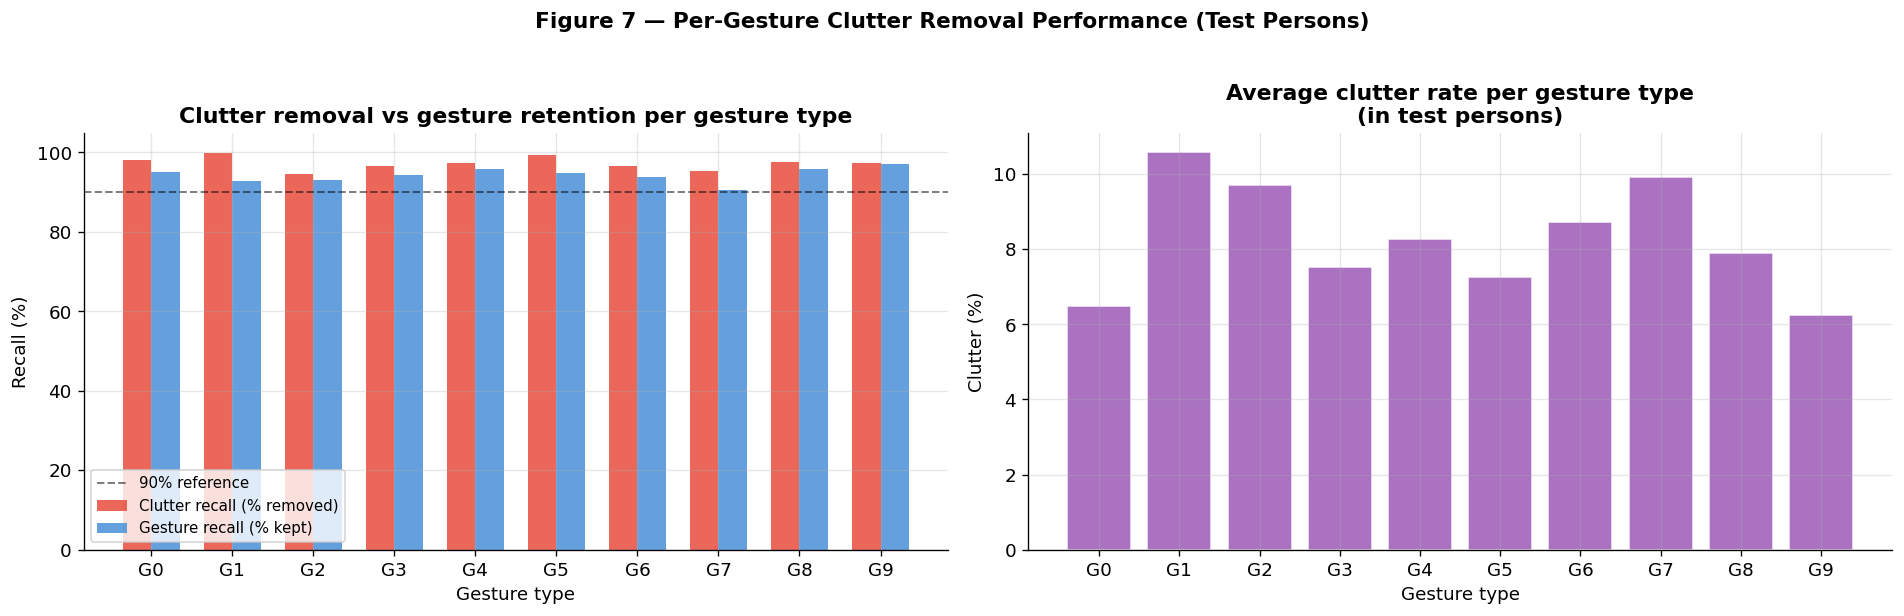


Per-gesture summary:
 gesture  clutter_recall  gesture_recall  clutter_pct
       0           0.982           0.951        6.499
       1           0.998           0.929       10.577
       2           0.945           0.932        9.716
       3           0.965           0.943        7.523
       4           0.975           0.958        8.278
       5           0.993           0.947        7.267
       6           0.967           0.939        8.718
       7           0.953           0.907        9.930
       8           0.976           0.958        7.893
       9           0.973           0.972        6.260


In [36]:
import numpy as np
# ── Figure 7: Clutter recall per gesture type ──────────────────────────────
# How well does the model remove clutter for each gesture?

gesture_metrics = []
test_keys = [k for k in common_keys
             if int(k[0].replace('Person','')) in test_persons]

for key in tqdm(test_keys, desc='Evaluating by gesture'):
    person, gesture_id, trial = key
    cfar_d = np.load(io.BytesIO(zf.read(cfar_paths[key])), allow_pickle=True)
    gt_d   = np.load(io.BytesIO(zf.read(gt_paths[key])),   allow_pickle=True)

    # Determine the minimum number of frames between cfar_d and gt_d
    min_frames = min(cfar_d.shape[0], gt_d.shape[0])

    # Slice both arrays to the minimum number of frames
    cfar_d_sliced = cfar_d[:min_frames]
    gt_d_sliced = gt_d[:min_frames]

    n_f    = min_frames

    feats, true_labels = [], []
    for t in range(n_f):
        wf = []
        for dt in range(-WINDOW, WINDOW + 1):
            ft = t + dt
            wf.extend(frame_context(cfar_d_sliced[ft], 0) + frame_context(cfar_d_sliced[ft], 1)
                      if 0 <= ft < n_f else [0.0] * 6)
        gt_entry = gt_d_sliced[t]
        gt_pts   = np.atleast_2d(gt_entry) if gt_entry is not None else np.empty((0,2))
        for si in range(2):
            for det in cfar_d_sliced[t, si]:
                r, v = det
                lbl = (1 if len(gt_pts) and
                       np.linalg.norm(gt_pts - [r,v], axis=1).min() < MATCH_THR
                       else 0)
                feats.append([r, v, float(si), t / max(n_f-1,1)] + wf)
                true_labels.append(lbl)

    if not feats:
        continue
    Xg = scaler.transform(np.array(feats, dtype=np.float32))
    with torch.no_grad():
        preds_g = model(torch.tensor(Xg).to(DEVICE)).cpu().argmax(1).numpy()
    true_labels = np.array(true_labels)

    clutter_mask  = true_labels == 0
    gesture_mask  = true_labels == 1
    clutter_recall = (preds_g[clutter_mask] == 0).mean() if clutter_mask.any() else np.nan
    gesture_recall = (preds_g[gesture_mask] == 1).mean() if gesture_mask.any() else np.nan
    clutter_pct    = clutter_mask.mean() * 100

    gesture_metrics.append({
        'gesture'        : gesture_id,
        'clutter_recall' : clutter_recall,
        'gesture_recall' : gesture_recall,
        'clutter_pct'    : clutter_pct,
    })

df_gm = pd.DataFrame(gesture_metrics).groupby('gesture').mean().reset_index()

x = np.arange(len(df_gm))
w = 0.35
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Clutter recall (how much clutter was removed)
axes[0].bar(x - w/2, df_gm['clutter_recall'] * 100, w,
            color=C['clutter'], alpha=0.85, label='Clutter recall (% removed)')
axes[0].bar(x + w/2, df_gm['gesture_recall'] * 100, w,
            color=C['gesture'], alpha=0.85, label='Gesture recall (% kept)')
axes[0].axhline(90, color='black', lw=1.2, linestyle='--', alpha=0.5, label='90% reference')
axes[0].set_title('Clutter removal vs gesture retention per gesture type',
                  fontweight='bold')
axes[0].set_ylabel('Recall (%)')
axes[0].set_ylim(0, 105)
axes[0].set_xticks(x)
axes[0].set_xticklabels([f'G{g}' for g in df_gm['gesture']])
axes[0].set_xlabel('Gesture type')
axes[0].legend(fontsize=9)

# Clutter rate per gesture
axes[1].bar(x, df_gm['clutter_pct'], color='#9B59B6', alpha=0.85, edgecolor='white')
axes[1].set_title('Average clutter rate per gesture type\n(in test persons)',
                  fontweight='bold')
axes[1].set_ylabel('Clutter (%)')
axes[1].set_xticks(x)
axes[1].set_xticklabels([f'G{g}' for g in df_gm['gesture']])
axes[1].set_xlabel('Gesture type')

fig.suptitle('Figure 7 — Per-Gesture Clutter Removal Performance (Test Persons)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig7_bygesture.png', bbox_inches='tight')
plt.show()

print('\nPer-gesture summary:')
print(df_gm.round(3).to_string(index=False))

---
## Part 9 · Final Summary

In [37]:
# ── Save model ─────────────────────────────────────────────────────────────
torch.save({'model_state_dict': model.state_dict(),
            'input_dim': X_tr_s.shape[1],
            'window': WINDOW,
            'match_threshold': MATCH_THR}, 'robust_radar_net.pt')
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# ── Print summary ──────────────────────────────────────────────────────────
gesture_recall_te = (preds_te[y_te == 1] == 1).mean()
clutter_recall_te = (preds_te[y_te == 0] == 0).mean()

print('=' * 58)
print('  Robust FMCW Radar — Clutter Removal Results')
print('=' * 58)
print()
print('MODEL')
print(f'  Architecture : MLP with temporal context (±{WINDOW} frames)')
print(f'  Parameters   : {n_params:,}')
print(f'  Input dim    : {X_tr_s.shape[1]} features per detection')
print()
print('DATASET')
print(f'  Total samples  : {len(y):,}')
print(f'  Gesture (real) : {(y==1).sum():,}  ({(y==1).mean()*100:.1f}%)')
print(f'  Clutter        : {(y==0).sum():,}  ({(y==0).mean()*100:.1f}%)')
print()
print('RESULTS (test set — unseen persons)')
print(f'  ROC-AUC          : {auc:.4f}')
print(f'  Average Precision: {ap:.4f}')
print(f'  Gesture recall   : {gesture_recall_te:.3f}  ({gesture_recall_te*100:.1f}% of real gestures kept)')
print(f'  Clutter recall   : {clutter_recall_te:.3f}  ({clutter_recall_te*100:.1f}% of clutter removed)')
print()
print('SPLIT (no data leakage — by person)')
print(f'  Train : Persons {sorted(np.unique(gv[train_idx]))}')
print(f'  Val   : Persons {sorted(np.unique(gv[val_idx]))}')
print(f'  Test  : Persons {sorted(np.unique(groups[test_idx]))}')
print()
print('OUTPUT FILES')
for fig_name, desc in [
    ('fig1_clutter_problem.png',    'The clutter problem visualized'),
    ('fig2_clutter_stats.png',      'Clutter distribution across dataset'),
    ('fig3_temporal_consistency.png','Why temporal context matters'),
    ('fig4_training.png',           'Training history'),
    ('fig5_classification.png',     'ROC, PR curve, confusion matrix'),
    ('fig6_pipeline.png',           'Before/after clutter removal'),
    ('fig7_bygesture.png',          'Per-gesture performance'),
]:
    print(f'  {fig_name:40s} — {desc}')
print('=' * 58)

  Robust FMCW Radar — Clutter Removal Results

MODEL
  Architecture : MLP with temporal context (±3 frames)
  Parameters   : 54,210
  Input dim    : 46 features per detection

DATASET
  Total samples  : 125,000
  Gesture (real) : 117,817  (94.3%)
  Clutter        : 7,183  (5.7%)

RESULTS (test set — unseen persons)
  ROC-AUC          : 0.9877
  Average Precision: 0.9988
  Gesture recall   : 0.937  (93.7% of real gestures kept)
  Clutter recall   : 0.948  (94.8% of clutter removed)

SPLIT (no data leakage — by person)
  Train : Persons [np.int64(1), np.int64(4), np.int64(5), np.int64(6), np.int64(8), np.int64(10)]
  Val   : Persons [np.int64(3), np.int64(7)]
  Test  : Persons [np.int64(2), np.int64(9)]

OUTPUT FILES
  fig1_clutter_problem.png                 — The clutter problem visualized
  fig2_clutter_stats.png                   — Clutter distribution across dataset
  fig3_temporal_consistency.png            — Why temporal context matters
  fig4_training.png                        —

---
## Part 10 · Interactive Explorer — Try Any Trial

Use this cell to **manually inspect any trial** in the dataset — with or without Ground Truth.

This is the real-world scenario: in deployment, there is no GT. The network must work on its own.
If the filtered signal looks cleaner and more temporally consistent than the raw one,
the network is doing its job.

**How to use:** Set `PERSON`, `GESTURE`, and `TRIAL` below and run the cell.
- Valid persons  : `'Person1'` through `'Person10'`
- Valid gestures : `0` through `9`
- Valid trials   : typically `1` through `10` (depends on the dataset)

✅  Person  : Person9
   Gesture : 9
   Trial   : 001
   GT available: No — running blind 🔍


/tmp/ipykernel_7986/2391994295.py:130: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig('fig_explorer.png', bbox_inches='tight')
/tmp/ipykernel_7986/2391994295.py:130: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  plt.savefig('fig_explorer.png', bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


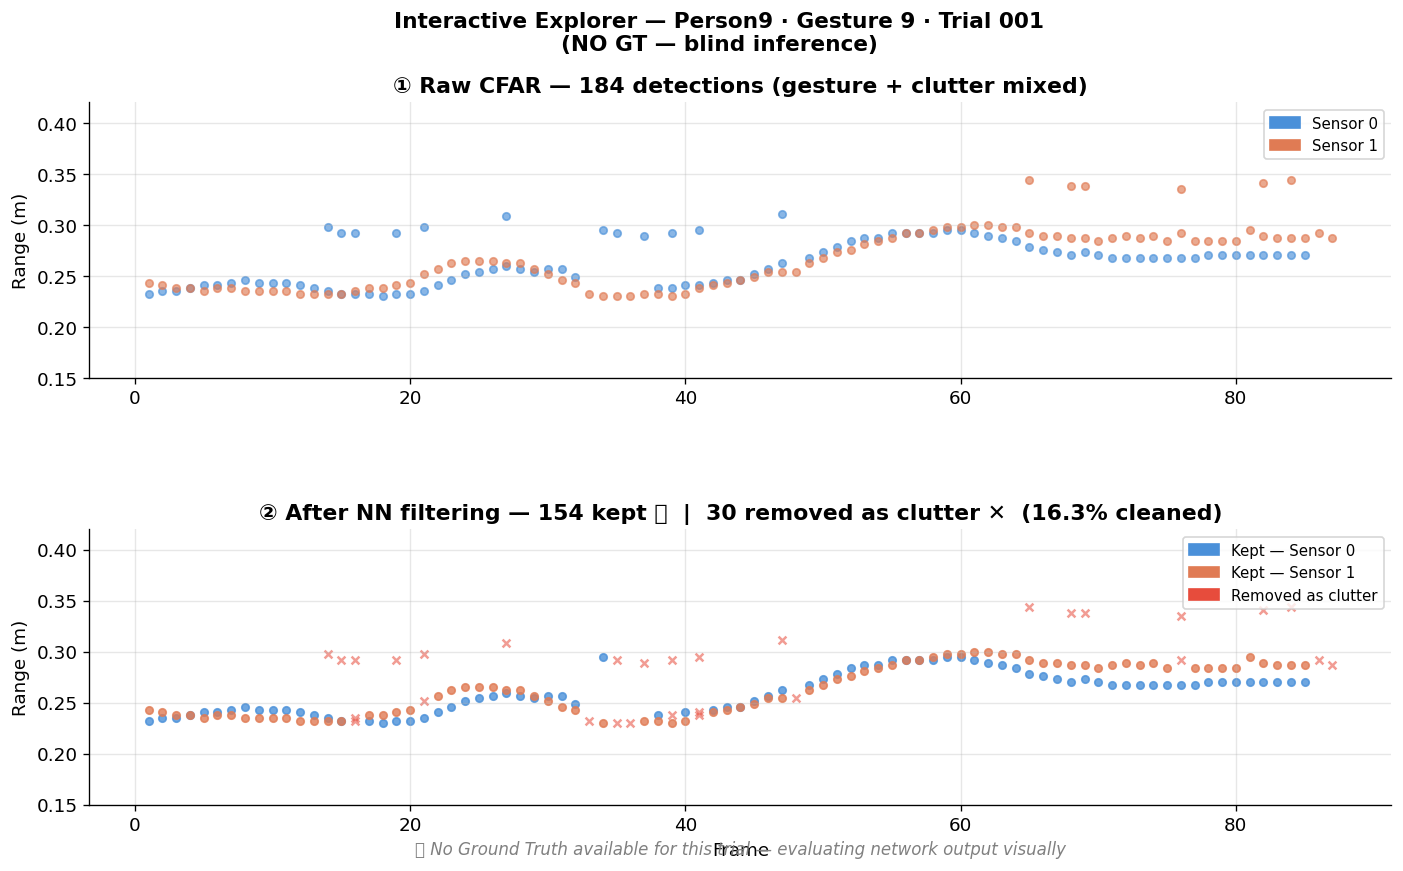

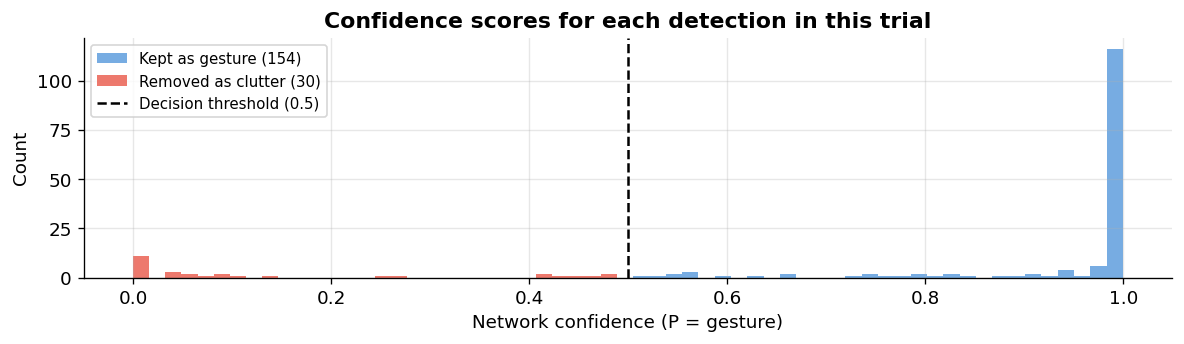


Summary for Person9 / Gesture 9 / Trial 001:
  Total CFAR detections : 184
  Kept as gesture       : 154  (83.7%)
  Removed as clutter    : 30  (16.3%)
  Avg confidence (kept) : 0.946
  Avg confidence (removed): 0.146

  ℹ️  No GT for this trial. Visual check: does the filtered
     signal (row ②) look more continuous and less noisy
     than the raw CFAR (row ①)? If yes, the model is working.


In [42]:
# ═══════════════════════════════════════════════════════
#   CHOOSE YOUR TRIAL HERE
# ═══════════════════════════════════════════════════════
PERSON  = 'Person9'   # e.g. 'Person1' ... 'Person10'
GESTURE = 9           # e.g. 0 ... 9
TRIAL   = 1           # e.g. 1 ... 10
# ══════════════════════════════════════════════════════

key = (PERSON, GESTURE, TRIAL)

# ── Check availability ────────────────────────────────────────────────────
has_cfar = key in cfar_paths
has_gt   = key in gt_paths

if not has_cfar:
    available = sorted([k for k in cfar_paths if k[0] == PERSON])
    print(f'❌  No CFAR data found for {PERSON} / Gesture {GESTURE} / Trial {TRIAL}.')
    print(f'   Available trials for {PERSON}: {[(k[1], k[2]) for k in available]}')
else:
    print(f'✅  Person  : {PERSON}')
    print(f'   Gesture : {GESTURE}')
    print(f'   Trial   : {TRIAL:03d}')
    print(f'   GT available: {"Yes ✅" if has_gt else "No — running blind 🔍"}')

    # ── Load CFAR ────────────────────────────────────────────────────────
    cfar_ex = np.load(io.BytesIO(zf.read(cfar_paths[key])), allow_pickle=True)
    gt_ex   = (np.load(io.BytesIO(zf.read(gt_paths[key])), allow_pickle=True)
               if has_gt else None)
    n_f = cfar_ex.shape[0]

    # ── Build features ───────────────────────────────────────────────────
    ex_feats, ex_coords = [], []
    for t in range(n_f):
        wf = []
        for dt in range(-WINDOW, WINDOW + 1):
            ft = t + dt
            wf.extend(frame_context(cfar_ex[ft], 0) + frame_context(cfar_ex[ft], 1)
                      if 0 <= ft < n_f else [0.0] * 6)
        for si in range(2):
            for det in cfar_ex[t, si]:
                r, v = det
                ex_feats.append([r, v, float(si), t / max(n_f - 1, 1)] + wf)
                ex_coords.append((t, r, v, si))

    if not ex_feats:
        print('⚠️  No CFAR detections found in this trial.')
    else:
        # ── Run the model ────────────────────────────────────────────────
        X_ex = scaler.transform(np.array(ex_feats, dtype=np.float32))
        model.eval()
        with torch.no_grad():
            logits_ex = model(torch.tensor(X_ex).to(DEVICE)).cpu()
        probs_ex = torch.softmax(logits_ex, 1)[:, 1].numpy()
        preds_ex = (probs_ex >= 0.5).astype(int)

        n_total   = len(preds_ex)
        n_kept    = (preds_ex == 1).sum()
        n_removed = (preds_ex == 0).sum()

        # ── Figure ───────────────────────────────────────────────────────
        n_rows = 3 if has_gt else 2
        fig = plt.figure(figsize=(14, 3.8 * n_rows))
        gs  = gridspec.GridSpec(n_rows, 1, hspace=0.55)
        axes = [fig.add_subplot(gs[i]) for i in range(n_rows)]

        # Row 1 — Raw CFAR
        for (t, r, v, si) in ex_coords:
            axes[0].scatter(t, r, s=20, alpha=0.65,
                            color=C['sensor0'] if si == 0 else C['sensor1'])
        axes[0].set_title(
            f'① Raw CFAR — {n_total} detections (gesture + clutter mixed)',
            fontweight='bold')
        axes[0].legend(handles=[
            mpatches.Patch(color=C['sensor0'], label='Sensor 0'),
            mpatches.Patch(color=C['sensor1'], label='Sensor 1'),
        ], fontsize=9, loc='upper right')

        # Row 2 — NN filtered (kept = colored, removed = red X)
        for (t, r, v, si), pred, prob in zip(ex_coords, preds_ex, probs_ex):
            if pred == 0:
                axes[1].scatter(t, r, s=22, alpha=0.55,
                                color=C['clutter'], marker='x', linewidths=1.5)
            else:
                axes[1].scatter(t, r, s=20, alpha=0.80,
                                color=C['sensor0'] if si == 0 else C['sensor1'])
        axes[1].set_title(
            f'② After NN filtering — '
            f'{n_kept} kept ✅  |  {n_removed} removed as clutter ✕  '
            f'({n_removed/n_total*100:.1f}% cleaned)',
            fontweight='bold')
        axes[1].legend(handles=[
            mpatches.Patch(color=C['sensor0'], label='Kept — Sensor 0'),
            mpatches.Patch(color=C['sensor1'], label='Kept — Sensor 1'),
            mpatches.Patch(color=C['clutter'], label='Removed as clutter'),
        ], fontsize=9, loc='upper right')

        # Row 3 — Ground Truth (only if available)
        if has_gt:
            for t, entry in enumerate(gt_ex):
                if entry is not None:
                    pts = np.atleast_2d(entry)
                    axes[2].scatter([t] * len(pts), pts[:, 0],
                                    s=22, color=C['gt'], alpha=0.9)
            axes[2].set_title('③ Ground Truth trajectory (reference)',
                              fontweight='bold')
            axes[2].legend(handles=[
                mpatches.Patch(color=C['gt'], label='Ground Truth')
            ], fontsize=9, loc='upper right')
            axes[2].set_xlabel('Frame')
        else:
            axes[1].set_xlabel('Frame')
            # Annotate that we are running without GT
            axes[1].annotate(
                '🔍 No Ground Truth available for this trial — '
                'evaluating network output visually',
                xy=(0.5, -0.18), xycoords='axes fraction',
                ha='center', fontsize=10, color='gray', style='italic'
            )

        for ax in axes:
            ax.set_ylabel('Range (m)')
            ax.set_ylim(0.15, 0.42)

        gt_label = 'with GT reference' if has_gt else 'NO GT — blind inference'
        fig.suptitle(
            f'Interactive Explorer — {PERSON} · Gesture {GESTURE} · Trial {TRIAL:03d}\n'
            f'({gt_label})',
            fontsize=13, fontweight='bold'
        )
        plt.savefig('fig_explorer.png', bbox_inches='tight')
        plt.show()

        # ── Confidence distribution ───────────────────────────────────────
        fig2, ax2 = plt.subplots(figsize=(10, 3))
        ax2.hist(probs_ex[preds_ex == 1], bins=30, alpha=0.75,
                 color=C['gesture'], label=f'Kept as gesture ({n_kept})')
        ax2.hist(probs_ex[preds_ex == 0], bins=30, alpha=0.75,
                 color=C['clutter'], label=f'Removed as clutter ({n_removed})')
        ax2.axvline(0.5, color='black', lw=1.5, linestyle='--', label='Decision threshold (0.5)')
        ax2.set_xlabel('Network confidence (P = gesture)')
        ax2.set_ylabel('Count')
        ax2.set_title('Confidence scores for each detection in this trial',
                      fontweight='bold')
        ax2.legend(fontsize=9)
        plt.tight_layout()
        plt.savefig('fig_explorer_confidence.png', bbox_inches='tight')
        plt.show()

        print(f'\nSummary for {PERSON} / Gesture {GESTURE} / Trial {TRIAL:03d}:')
        print(f'  Total CFAR detections : {n_total}')
        print(f'  Kept as gesture       : {n_kept}  ({n_kept/n_total*100:.1f}%)')
        print(f'  Removed as clutter    : {n_removed}  ({n_removed/n_total*100:.1f}%)')
        print(f'  Avg confidence (kept) : {probs_ex[preds_ex==1].mean():.3f}')
        print(f'  Avg confidence (removed): {probs_ex[preds_ex==0].mean():.3f}')
        if not has_gt:
            print()
            print('  ℹ️  No GT for this trial. Visual check: does the filtered')
            print('     signal (row ②) look more continuous and less noisy')
            print('     than the raw CFAR (row ①)? If yes, the model is working.')